Current computation device: cuda
Loading the FULL dataset...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Starting Training for 3 Epochs with Global Gradient Tracking...
  Epoch 1 | Batch 500/5430 | Train Loss: 0.7103
  Epoch 1 | Batch 1000/5430 | Train Loss: 0.7726
  Epoch 1 | Batch 1500/5430 | Train Loss: 0.7388
  Epoch 1 | Batch 2000/5430 | Train Loss: 0.4139
  Epoch 1 | Batch 2500/5430 | Train Loss: 0.8007
  Epoch 1 | Batch 3000/5430 | Train Loss: 0.6252
  Epoch 1 | Batch 3500/5430 | Train Loss: 0.2749
  Epoch 1 | Batch 4000/5430 | Train Loss: 0.6099
  Epoch 1 | Batch 4500/5430 | Train Loss: 0.3963
  Epoch 1 | Batch 5000/5430 | Train Loss: 0.5627
--> [Gradient Stats] Epoch 1 | CF Avg Grad: 0.0386 | Text Avg Grad: 1.0017
=== Epoch 1 Summary | Train Loss: 0.8422 | Test RMSE: 0.7725 | Test MAE: 0.4604 ===

  Epoch 2 | Batch 500/5430 | Train Loss: 0.4096
  Epoch 2 | Batch 1000/5430 | Train Loss: 0.3156
  Epoch 2 | Batch 1500/5430 | Train Loss: 0.3167
  Epoch 2 | Batch 2000/5430 | Train Loss: 0.2479
  Epoch 2 | Batch 2500/5430 | Train Loss: 0.8919
  Epoch 2 | Batch 3000/5430 | Train Loss:

Evaluating Hybrid Model: 100%|██████████| 1000/1000 [10:21<00:00,  1.61it/s]



 Hybrid Evaluation Complete!
Sampled Precision@10: 0.0213
Sampled Recall@10: 0.1069
Sampled NDCG@10: 0.0615

 All evaluation metrics successfully updated in /content/final_hybrid_results.json!


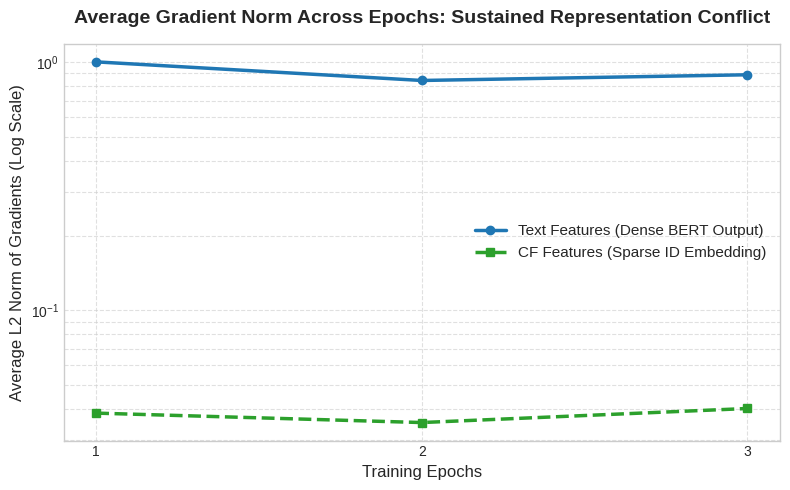

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import math
import json
import time
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

# ================= 1. Basic Settings and Data Loading =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current computation device: {device}")

print("Loading the FULL dataset...")
train_df = pd.read_json('/content/train_indexed.jsonl', lines=True)
test_df = pd.read_json('/content/test_indexed.jsonl', lines=True)

train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)
train_df['rating'] = train_df['rating'].astype(float)
test_df['rating'] = test_df['rating'].astype(float)

num_users = max(train_df['user_idx'].max(), test_df['user_idx'].max()) + 1
num_items = max(train_df['item_idx'].max(), test_df['item_idx'].max()) + 1

# ================= 2. Dataset and Model Definition =================
class HybridDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts = df['text'].values
        self.users = df['user_idx'].values
        self.items = df['item_idx'].values
        self.ratings = df['rating'].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'user_idx': torch.tensor(self.users[idx], dtype=torch.long),
            'item_idx': torch.tensor(self.items[idx], dtype=torch.long),
            'rating': torch.tensor(self.ratings[idx], dtype=torch.float)
        }

class AspectAttentionHybridModel(nn.Module):
    def __init__(self, num_users, num_items):
        super(AspectAttentionHybridModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        for param in self.bert.encoder.layer[-2:].parameters():
            param.requires_grad = True

        self.user_embedding = nn.Embedding(num_users, 64)
        self.item_embedding = nn.Embedding(num_items, 64)
        self.query_proj = nn.Linear(128, 768)

        self.mlp = nn.Sequential(
            nn.Linear(896, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, user_idx, item_idx, return_attention=False):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = bert_output.last_hidden_state

        u_feat = self.user_embedding(user_idx)
        i_feat = self.item_embedding(item_idx)

        ui_query = torch.cat([u_feat, i_feat], dim=-1)
        query = self.query_proj(ui_query).unsqueeze(1)

        attention_scores = torch.bmm(query, token_embeddings.transpose(1, 2))
        extended_mask = (1.0 - attention_mask.unsqueeze(1)) * -10000.0
        attention_scores = attention_scores + extended_mask
        attention_weights = F.softmax(attention_scores, dim=-1)

        attended_text = torch.bmm(attention_weights, token_embeddings).squeeze(1)
        combined_feat = torch.cat((attended_text, u_feat, i_feat), dim=1)
        prediction = self.mlp(combined_feat).squeeze()

        if return_attention:
            return prediction, attention_weights.squeeze(1)
        return prediction

# ================= 3. Model Initialization and Training =================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_loader = DataLoader(HybridDataset(train_df, tokenizer), batch_size=32, shuffle=True)
test_loader = DataLoader(HybridDataset(test_df, tokenizer), batch_size=32, shuffle=False)

model = AspectAttentionHybridModel(num_users, num_items).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5)

epochs = 3
epoch_cf_grads, epoch_text_grads = [], []
rmse, mae = 0.0, 0.0

print(f"\n Starting Training for {epochs} Epochs with Global Gradient Tracking...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    epoch_cf_grad_sum, epoch_text_grad_sum = 0.0, 0.0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        user_idx = batch['user_idx'].to(device)
        item_idx = batch['item_idx'].to(device)
        ratings = batch['rating'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask, user_idx, item_idx)
        loss = criterion(preds, ratings)
        loss.backward()

        if model.user_embedding.weight.grad is not None:
            epoch_cf_grad_sum += model.user_embedding.weight.grad.norm(2).item()
        if model.bert.encoder.layer[-1].output.dense.weight.grad is not None:
            epoch_text_grad_sum += model.bert.encoder.layer[-1].output.dense.weight.grad.norm(2).item()

        optimizer.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 500 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Train Loss: {loss.item():.4f}")

    num_batches = len(train_loader)
    avg_cf_grad = epoch_cf_grad_sum / num_batches
    avg_text_grad = epoch_text_grad_sum / num_batches
    epoch_cf_grads.append(avg_cf_grad)
    epoch_text_grads.append(avg_text_grad)
    print(f"--> [Gradient Stats] Epoch {epoch+1} | CF Avg Grad: {avg_cf_grad:.4f} | Text Avg Grad: {avg_text_grad:.4f}")

    # RMSE / MAE Evaluation
    model.eval()
    test_preds, test_trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            preds_eval = model(batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['user_idx'].to(device), batch['item_idx'].to(device)).cpu().numpy()
            if preds_eval.ndim == 0: preds_eval = np.expand_dims(preds_eval, axis=0)
            test_preds.extend(preds_eval.tolist())
            test_trues.extend(batch['rating'].tolist())

    rmse = math.sqrt(mean_squared_error(test_trues, test_preds))
    mae = mean_absolute_error(test_trues, test_preds)
    print(f"=== Epoch {epoch+1} Summary | Train Loss: {total_loss/len(train_loader):.4f} | Test RMSE: {rmse:.4f} | Test MAE: {mae:.4f} ===\n")

# ================= 4. Securely Save Model =================
save_path = '/content/attention_hybrid_model.pth'
torch.save(model.state_dict(), save_path)
print("Model weights saved to memory cache...")

drive.flush_and_unmount()
print("Drive flushed. Re-mounting...")
drive.mount('/content/drive')
time.sleep(5)
print(f" Successfully saved Hybrid Model to {save_path}")

# ================= 5. Top-10 Sampled Evaluation =================
print("\n Performing FAIR Sampled Top-10 Evaluation (Target + 99 Negatives)...")

item_profiles_df = train_df.groupby('item_idx')['text'].apply(lambda x: ' '.join(x)).reset_index()
item_profiles = dict(zip(item_profiles_df['item_idx'], item_profiles_df['text']))
all_items = set(train_df['item_idx'].unique()).union(set(test_df['item_idx'].unique()))
for i in all_items:
    if i not in item_profiles:
        item_profiles[i] = ""

train_user_items = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
test_user_items = test_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
all_items_list = list(all_items)

def calculate_ndcg_sampled(recommended_list, interacted_set):
    dcg = sum([1.0 / math.log2(i + 2) for i, item in enumerate(recommended_list) if item in interacted_set])
    idcg = sum([1.0 / math.log2(i + 2) for i in range(min(len(interacted_set), len(recommended_list)))])
    return dcg / idcg if idcg > 0 else 0.0

random.seed(42)
test_users_full = list(test_user_items.keys())
evaluate_users_sampled = random.sample(test_users_full, min(1000, len(test_users_full)))

total_precision_samp, total_recall_samp, total_ndcg_samp = 0.0, 0.0, 0.0
valid_users_count = 0

model.eval()
with torch.no_grad():
    for u in tqdm(evaluate_users_sampled, desc="Evaluating Hybrid Model"):
        true_items = test_user_items.get(u, set())
        if not true_items: continue

        seen_items = train_user_items.get(u, set()).union(true_items)
        negative_items = set()
        while len(negative_items) < 99:
            rand_item = random.choice(all_items_list)
            if rand_item not in seen_items:
                negative_items.add(rand_item)

        candidate_items = list(true_items) + list(negative_items)
        candidate_texts = [item_profiles[i] for i in candidate_items]

        encoded_inputs = tokenizer(candidate_texts, max_length=64, padding='max_length', truncation=True, return_tensors='pt')
        scores = model(encoded_inputs['input_ids'].to(device), encoded_inputs['attention_mask'].to(device),
                       torch.tensor([u] * len(candidate_items), dtype=torch.long).to(device),
                       torch.tensor(candidate_items, dtype=torch.long).to(device)).cpu().numpy()

        item_score_pairs = list(zip(candidate_items, scores))
        item_score_pairs.sort(key=lambda x: x[1], reverse=True)
        top_10_items = [pair[0] for pair in item_score_pairs[:10]]

        hits = len(set(top_10_items) & true_items)
        total_precision_samp += hits / 10.0
        total_recall_samp += hits / len(true_items)
        total_ndcg_samp += calculate_ndcg_sampled(top_10_items, true_items)
        valid_users_count += 1

final_precision_samp = total_precision_samp / valid_users_count
final_recall_samp = total_recall_samp / valid_users_count
final_ndcg_samp = total_ndcg_samp / valid_users_count

print(f"\n Hybrid Evaluation Complete!")
print(f"Sampled Precision@10: {final_precision_samp:.4f}")
print(f"Sampled Recall@10: {final_recall_samp:.4f}")
print(f"Sampled NDCG@10: {final_ndcg_samp:.4f}")

# ================= 6. Save All Metrics to Unified Log =================
log_path = '/content/final_hybrid_results.json'

new_results_entry = {
    "model_name": "Attention-Based Hybrid Model - Fair Sampled",
    "RMSE": float(rmse),
    "MAE": float(mae),
    "Precision_10": float(final_precision_samp),
    "Recall_10": float(final_recall_samp),
    "NDCG_10": float(final_ndcg_samp),
    "epochs": epochs,
    "eval_users": valid_users_count,
    "avg_cf_grads": epoch_cf_grads,
    "avg_text_grads": epoch_text_grads,
    "architecture": "Cross-Attention Dynamic Alignment"
}

if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        all_results = json.load(f)
    all_results = [res for res in all_results if "Full Eval" not in res.get("model_name", "")]
else:
    all_results = []

all_results.append(new_results_entry)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"\n All evaluation metrics successfully updated in {log_path}!")

# ================= 7. Plot Global Gradient Trend =================
epoch_list = list(range(1, epochs + 1))
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(epoch_list, epoch_text_grads, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, label='Text Features (Dense BERT Output)')
plt.plot(epoch_list, epoch_cf_grads, marker='s', linestyle='--', color='#2ca02c', linewidth=2.5, label='CF Features (Sparse ID Embedding)')

plt.title('Average Gradient Norm Across Epochs: Sustained Representation Conflict', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Average L2 Norm of Gradients (Log Scale)', fontsize=12)
plt.xticks(epoch_list)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


start extracting the model's attention weights...

[raw_text]: Very nice sound and sound cancelling.  Long batterie time. For the price you cant beat these head phones....bluetooth and plug in option.
[real_rating]: 5.0 star
[pred_score]: 4.92 star


/tmp/ipykernel_485/3449578014.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_weights, y=top_tokens, palette="viridis")


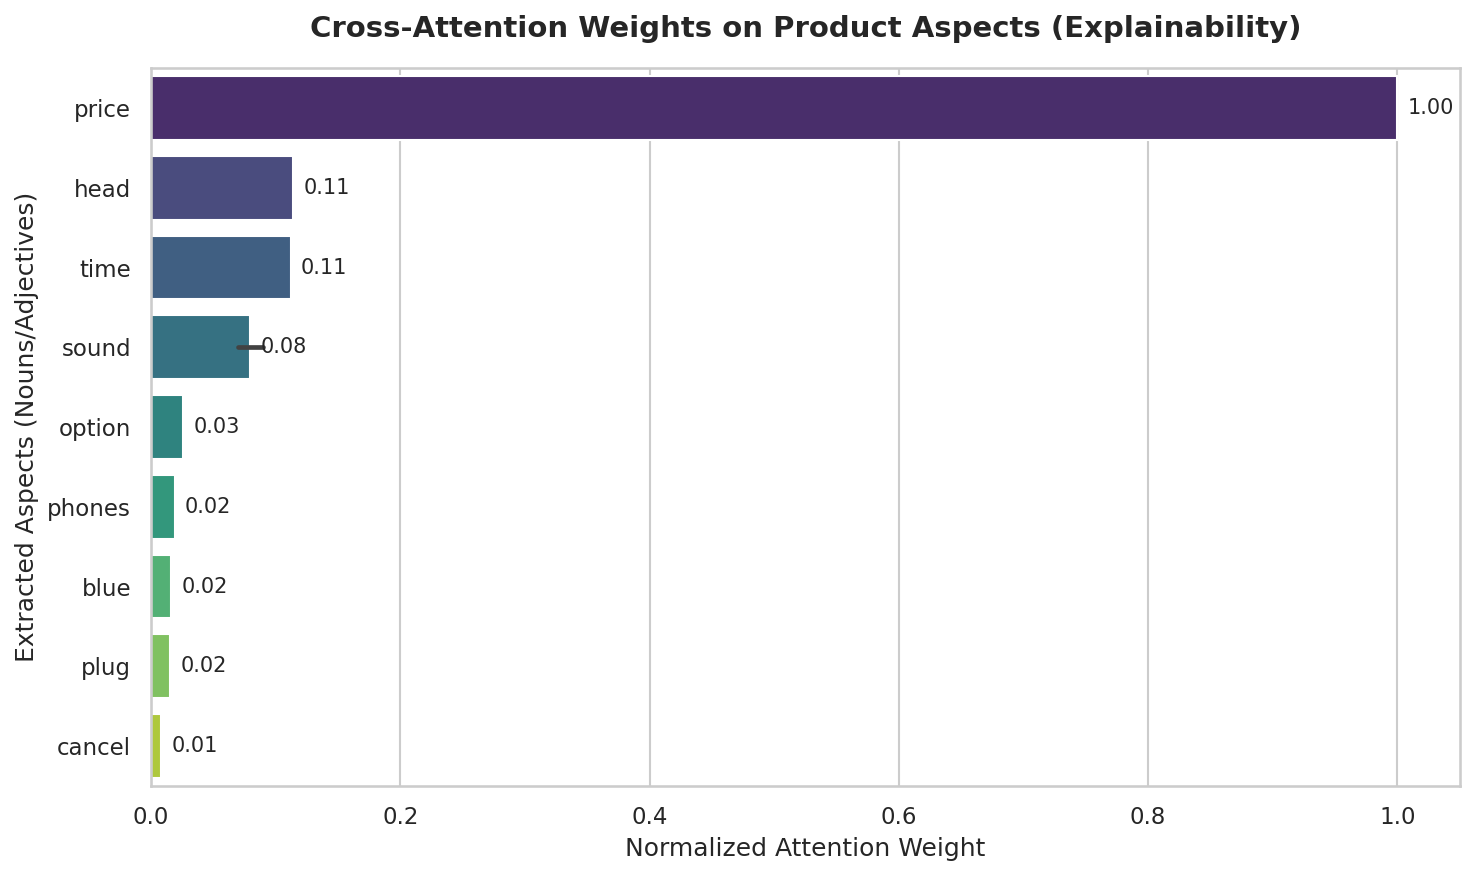


 success!save as attention_aspects_visualization.png


In [ ]:
# 1. Install and import visualization and NLP dependencies
!pip install -q seaborn nltk

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag

nltk.download('punkt')
nltk.download('punkt_tab') # Newer NLTK versions sometimes require this
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print("start extracting the model's attention weights...")

# 2. Select a test sample (Case Study)

# Select the 42nd entry
sample_row = test_df.dropna(subset=['text']).iloc[42]
u_idx = int(sample_row['user_idx'])
i_idx = int(sample_row['item_idx'])
raw_text = str(sample_row['text'])

print(f"\n[raw_text]: {raw_text}")
print(f"[real_rating]: {sample_row['rating']} star")

# 3. Data preprocessing and model inference
# Use BERT Tokenizer
encoded_inputs = tokenizer(
    raw_text,
    max_length=64,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

input_ids = encoded_inputs['input_ids'].to(device)
attention_mask = encoded_inputs['attention_mask'].to(device)
u_tensor = torch.tensor([u_idx], dtype=torch.long).to(device)
i_tensor = torch.tensor([i_idx], dtype=torch.long).to(device)

# Forward pass, with return_attention=True enabled here
with torch.no_grad():
    prediction, attn_weights = model(
        input_ids, attention_mask, u_tensor, i_tensor, return_attention=True
    )

pred_score = prediction.item()
print(f"[pred_score]: {pred_score:.2f} star")

# 4. Post-processing: Token alignment and Part-of-Speech (POS-tagging) filtering
# Convert tensor to numpy array
attn_weights = attn_weights.squeeze().cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

# Filter out special placeholders like [PAD], [CLS], [SEP]
valid_tokens = []
valid_weights = []
for token, weight in zip(tokens, attn_weights):
    if token not in ['[PAD]', '[CLS]', '[SEP]']:
        # Remove BERT subword marker '##'
        clean_token = token.replace('##', '')
        if clean_token.isalpha(): # Keep only pure alphabetic words
            valid_tokens.append(clean_token)
            valid_weights.append(weight)

# Perform Part-of-Speech (POS) tagging on the cleaned tokens
tagged_tokens = pos_tag(valid_tokens)

# [Core Logic]: Only keep nouns (NN, NNS) and adjectives (JJ), which typically represent product aspects and sentiment
aspect_tokens = []
aspect_weights = []

for (word, tag), weight in zip(tagged_tokens, valid_weights):
    if tag in ['NN', 'NNS', 'JJ'] and len(word) > 2: # Keep nouns and adjectives, and words longer than 2 characters
        aspect_tokens.append(word)
        aspect_weights.append(weight)

# If no words remain after filtering (rare case), fall back to using all valid words
if len(aspect_tokens) == 0:
    aspect_tokens, aspect_weights = valid_tokens, valid_weights

# Normalize weights for better plotting
aspect_weights = np.array(aspect_weights)
aspect_weights = (aspect_weights - aspect_weights.min()) / (aspect_weights.max() - aspect_weights.min() + 1e-9)

# Get the Top-10 aspect words with the highest weights
top_indices = np.argsort(aspect_weights)[::-1][:10]
top_tokens = [aspect_tokens[i] for i in top_indices]
top_weights = [aspect_weights[i] for i in top_indices]


# 5. Visualization

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

# Plot an elegant horizontal bar chart to show attention weights
ax = sns.barplot(x=top_weights, y=top_tokens, palette="viridis")

plt.title('Cross-Attention Weights on Product Aspects (Explainability)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Normalized Attention Weight', fontsize=12)
plt.ylabel('Extracted Aspects (Nouns/Adjectives)', fontsize=12)

# Annotate exact values on the bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.savefig('/content/attention_aspects_visualization.png')
plt.show()

print("\n success!save as attention_aspects_visualization.png")

 Start to execute the attention extraction using the [word-merging algorithm]...

[raw_text]: This worked perfectly. But after 2 months of light use it began to slowly die.<br /><br />It started with the hdmi output cutting in and out, less frequently at first. It got worse, until there was not longer hdmi output at all. It was at that same time that the HDMI out died that the entire unit died.<br /><br />If you need something for a week. Sure. Grab it. Otherwise… don’t trust this to live super long.
[real_rating]: 2.0 star
[pred_score]: 1.45 star


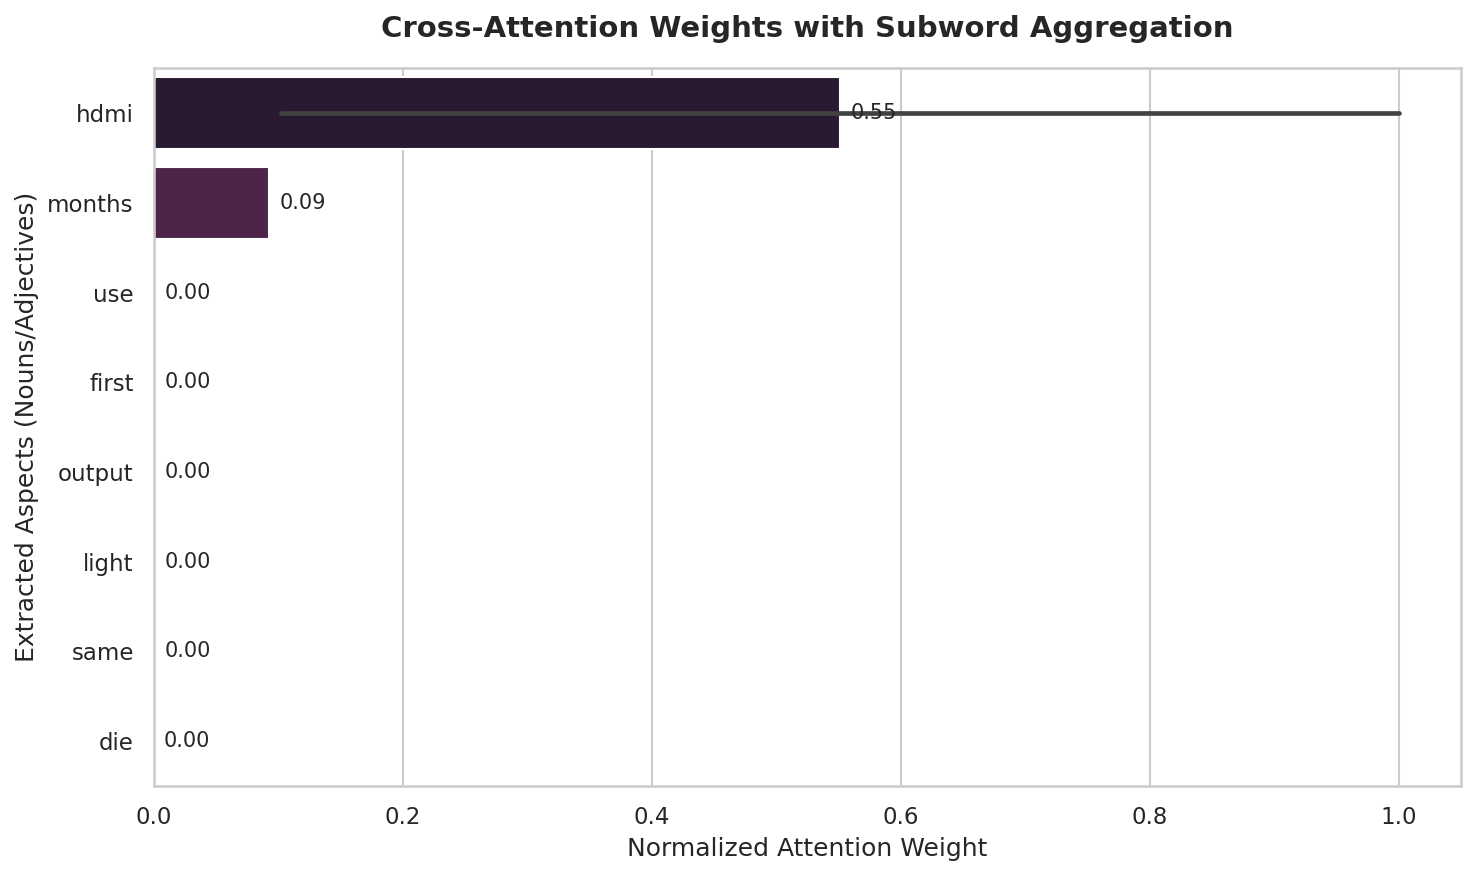


 success！saved as negative_attention_aggregated.png


In [ ]:
# Ensure model is in evaluation mode
model.eval()
model.to(device)

print(" Start to execute the attention extraction using the [word-merging algorithm]...")

# 1. Extract sample

bad_reviews_df = test_df[(test_df['rating'] <= 2.0)].dropna(subset=['text'])
sample_row = bad_reviews_df.sample(n=1, random_state=228).iloc[0]
u_idx = int(sample_row['user_idx'])
i_idx = int(sample_row['item_idx'])
raw_text = str(sample_row['text'])

print(f"\n[raw_text]: {raw_text}")
print(f"[real_rating]: {sample_row['rating']} star")

# 2. Model Inference

encoded_inputs = tokenizer(
    raw_text, max_length=64, padding='max_length', truncation=True, return_tensors='pt'
)
input_ids = encoded_inputs['input_ids'].to(device)
attention_mask = encoded_inputs['attention_mask'].to(device)
u_tensor = torch.tensor([u_idx], dtype=torch.long).to(device)
i_tensor = torch.tensor([i_idx], dtype=torch.long).to(device)

with torch.no_grad():
    prediction, attn_weights = model(
        input_ids, attention_mask, u_tensor, i_tensor, return_attention=True
    )
pred_score = prediction.item()
print(f"[pred_score]: {pred_score:.2f} star")

# 3. Core Innovation: Subword Aggregation Algorithm

attn_weights = attn_weights.squeeze().cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

merged_tokens = []
merged_weights = []

# Iterate through all tokens to perform merging logic
for token, weight in zip(tokens, attn_weights):
    if token in ['[PAD]', '[CLS]', '[SEP]']:
        continue

    if token.startswith('##'):
        # If it's a subword suffix, append to the previous word and take the maximum attention weight
        if len(merged_tokens) > 0:
            merged_tokens[-1] += token.replace('##', '')
            merged_weights[-1] = max(merged_weights[-1], weight)
    else:
        # If it's a new word, add directly to the list
        merged_tokens.append(token)
        merged_weights.append(weight)

# 4. Filtering and Part-of-Speech (POS-tagging)

valid_tokens = []
valid_weights = []
# Now filter out punctuation and keep only pure English words
for token, weight in zip(merged_tokens, merged_weights):
    if token.isalpha():
        valid_tokens.append(token)
        valid_weights.append(weight)

tagged_tokens = pos_tag(valid_tokens)

aspect_tokens = []
aspect_weights = []

for (word, tag), weight in zip(tagged_tokens, valid_weights):
    # Keep nouns and adjectives, and words longer than 2 characters
    if tag in ['NN', 'NNS', 'JJ'] and len(word) > 2:
        aspect_tokens.append(word)
        aspect_weights.append(weight)

if len(aspect_tokens) == 0:
    aspect_tokens, aspect_weights = valid_tokens, valid_weights

# Normalize weights
aspect_weights = np.array(aspect_weights)
aspect_weights = (aspect_weights - aspect_weights.min()) / (aspect_weights.max() - aspect_weights.min() + 1e-9)

top_indices = np.argsort(aspect_weights)[::-1][:10]
top_tokens = [aspect_tokens[i] for i in top_indices]
top_weights = [aspect_weights[i] for i in top_indices]

# 5. Visualization

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=top_weights, y=top_tokens, hue=top_tokens, palette="rocket", legend=False)

plt.title('Cross-Attention Weights with Subword Aggregation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Normalized Attention Weight', fontsize=12)
plt.ylabel('Extracted Aspects (Nouns/Adjectives)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.savefig('/content/negative_attention_aggregated.png')
plt.show()

print("\n success！saved as negative_attention_aggregated.png")